In [4]:
from PPOClip_Completo import PPO_Clip_Completo
from PPOClip_basic import PPO_Clip_Basic
from PPOClip_entropy import PPO_Clip_Entropy
from PPOClip_GAE import PPO_Clip_GAE
from PPOClip_Annealing import PPO_Clip_Annealing

from ValueNet import ValueNet
from PolicyNet import PolicyNet
import matplotlib.pyplot as plt 
import torch
# import flappy_bird_gymnasium
import gymnasium as gym
import numpy as np

from stable_baselines3 import PPO as PPO_sb3
from stable_baselines3.common.callbacks import BaseCallback
import os

from basic_envs import (
    TwoAZeroObsOneStep,
    TwoARandomObsOneStep,
    LineWorldEasyEnv,
    LineWorldMirrorEnv,
    ConstantRewardEnv,
    RandomObsBinaryRewardEnv,
    TwoStepDelayedRewardEnv
)

basic_envs_list = [
    ("TwoAZeroObsOneStep", TwoAZeroObsOneStep),
    ("TwoARandomObsOneStep", TwoARandomObsOneStep),
    ("LineWorldEasyEnv", LineWorldEasyEnv),
    ("LineWorldMirrorEnv", LineWorldMirrorEnv),
    ("ConstantRewardEnv", ConstantRewardEnv),
    ("RandomObsBinaryRewardEnv", RandomObsBinaryRewardEnv),
    ("TwoStepDelayedRewardEnv", TwoStepDelayedRewardEnv),
]



In [5]:
# def plot_metrics(modelo_entrenado, hiperparams):
#     reward = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["rewards"]
#     plt.plot(np.linspace(0, hiperparams["epochs"], len(reward)),reward)
#     plt.title("Recompensa entrenamiento")
#     plt.show()

#     entropy = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["entropy"]
#     if entropy is not None:
#         plt.plot(np.linspace(0, hiperparams["epochs"], len(entropy)),entropy)
#         plt.title("Entropía entrenamiento")
#         plt.show()

#     loss = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")["loss"]
#     plt.plot(np.linspace(0, hiperparams["epochs"], len(loss)),loss)
#     plt.title("Loss entrenamiento")
#     plt.show()

def plot_metrics(modelo_entrenado, hiperparams):
    metrics_path = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

    data = torch.load(metrics_path, weights_only=False)

    reward = data["rewards"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(reward)), reward)
    plt.title("Recompensa entrenamiento")
    plt.xlabel("Epochs")
    plt.show()

    entropy = data.get("entropy", None)
    if entropy is not None and len(entropy) > 0:
        plt.plot(np.linspace(0, hiperparams["epochs"], len(entropy)), entropy)
        plt.title("Entropía entrenamiento")
        plt.xlabel("Epochs")
        plt.show()

    loss = data["loss"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(loss)), loss)
    plt.title("Loss entrenamiento")
    plt.xlabel("Epochs")
    plt.show()


### CartPole-v1

In [6]:
env = gym.make("CartPole-v1")
policy_net_cartpole = PolicyNet(4, 2)
value_net_cartpole = ValueNet(4, 1)

hiperparams_cartpole = {
    "epochs": 150,
    "K": 24,               
    "batch_size": 64,     
    "policy_net": policy_net_cartpole,
    "value_net": value_net_cartpole,
    "clip_param": 0.2,      
    "lr": 3e-4,            
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 500   
}



In [7]:
modelo_entrenado = "PPO_CartPole_v1"
ppo_cartpole = PPO_Clip_Completo(hiperparams_cartpole)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/cartpole_actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/cartpole_critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_cartpole, loss_cartpole, entropy_cartpole = ppo_cartpole.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: 22.91
Guardando modelos...
Epoch 2/150 -- reward: 27.23
Guardando modelos...
Epoch 3/150 -- reward: 32.00
Guardando modelos...
Epoch 4/150 -- reward: 47.47
Guardando modelos...
Epoch 5/150 -- reward: 60.66
Guardando modelos...
Epoch 6/150 -- reward: 94.42
Guardando modelos...
Epoch 7/150 -- reward: 120.06
Guardando modelos...
Epoch 8/150 -- reward: 153.61
Guardando modelos...
Epoch 9/150 -- reward: 182.20
Guardando modelos...
Epoch 10/150 -- reward: 224.80
Guardando modelos...
Epoch 11/150 -- reward: 220.47
Epoch 12/150 -- reward: 241.30
Guardando modelos...
Epoch 13/150 -- reward: 293.44
Guardando modelos...
Epoch 14/150 -- reward: 321.02
Guardando modelos...
Epoch 15/150 -- reward: 290.14
Epoch 16/150 -- reward: 350.94
Guardando modelos...
Epoch 17/150 -- reward: 343.66
Epoch 18/150 -- reward: 289.30
Epoch 19/150 -- reward: 386.38
Guardando modelos...
Epoch 20/150 -- reward: 387.45
Guardando modelos...
Epoch 21/150 -- reward: 377.67
Epoch 22/150 -- reward: 426.

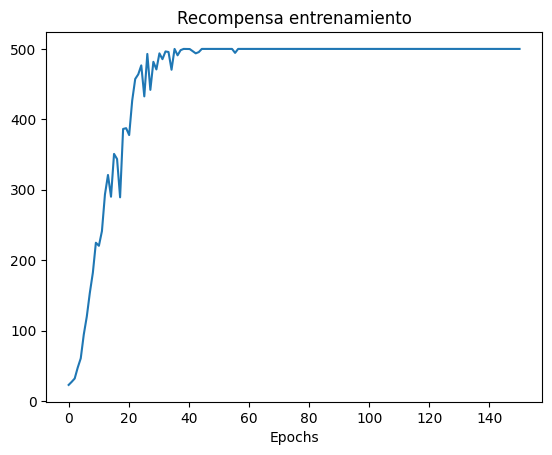

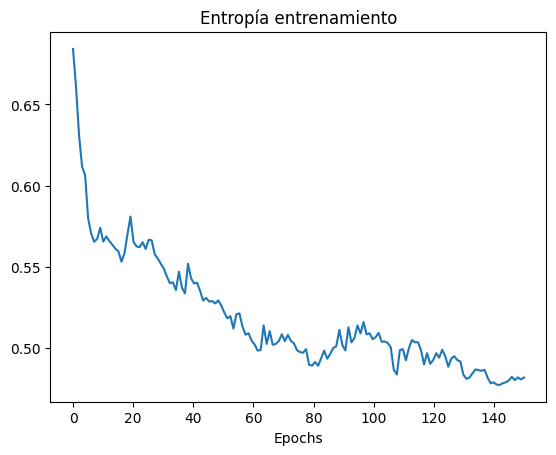

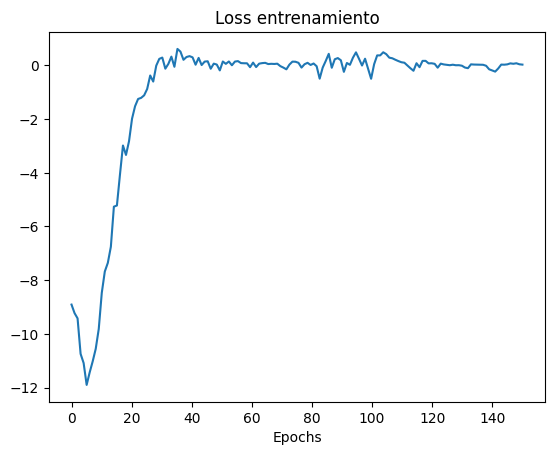

In [8]:
plot_metrics(modelo_entrenado, hiperparams_cartpole)

In [9]:
modelo_entrenado = "PPO_CartPole_v1"
env = gym.make("CartPole-v1", render_mode="human")
PPO = PPO_Clip_Completo(hiperparams_cartpole)

policy_net = PolicyNet(4, 2)

policy_net.load_state_dict(torch.load(f"trained_net/basicenvs/{modelo_entrenado}/cartpole_actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()

reward: 500.0 en 500 pasos
reward: 500.0 en 500 pasos
reward: 500.0 en 500 pasos


### TwoAZeroObsOneStep

In [10]:
env = TwoAZeroObsOneStep()
obs_dim = env.observation_space.n

policy_net_twoazeroobsonestep = PolicyNet(obs_dim, 2)
value_net_twoazeroobsonestep = ValueNet(obs_dim, 1)


hiperparams_twoazeroobsonestep = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_twoazeroobsonestep,
    "value_net": value_net_twoazeroobsonestep,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 1
}

In [11]:
modelo_entrenado = "PPO_TwoAZeroObsOneStep"
ppo_twoazeroobsonestep = PPO_Clip_Completo(hiperparams_twoazeroobsonestep)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_twoazeroobsonestep, loss_twoazeroobsonestep, entropy_twoazeroobsonestep = ppo_twoazeroobsonestep.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: 0.03
Guardando modelos...
Epoch 2/150 -- reward: 0.34
Guardando modelos...
Epoch 3/150 -- reward: 0.69
Guardando modelos...
Epoch 4/150 -- reward: 0.94
Guardando modelos...
Epoch 5/150 -- reward: 0.97
Guardando modelos...
Epoch 6/150 -- reward: 0.94
Epoch 7/150 -- reward: 0.97
Guardando modelos...
Epoch 8/150 -- reward: 1.00
Guardando modelos...
Epoch 9/150 -- reward: 1.00
Guardando modelos...
Epoch 10/150 -- reward: 0.97
Epoch 11/150 -- reward: 1.00
Guardando modelos...
Epoch 12/150 -- reward: 0.97
Epoch 13/150 -- reward: 1.00
Guardando modelos...
Epoch 14/150 -- reward: 1.00
Guardando modelos...
Epoch 15/150 -- reward: 0.97
Epoch 16/150 -- reward: 1.00
Guardando modelos...
Epoch 17/150 -- reward: 1.00
Guardando modelos...
Epoch 18/150 -- reward: 1.00
Guardando modelos...
Epoch 19/150 -- reward: 1.00
Guardando modelos...
Epoch 20/150 -- reward: 1.00
Guardando modelos...
Epoch 21/150 -- reward: 1.00
Guardando modelos...
Epoch 22/150 -- reward: 1.00
Guardando mode

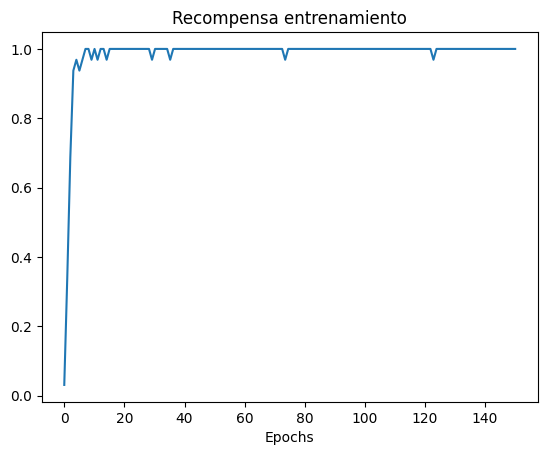

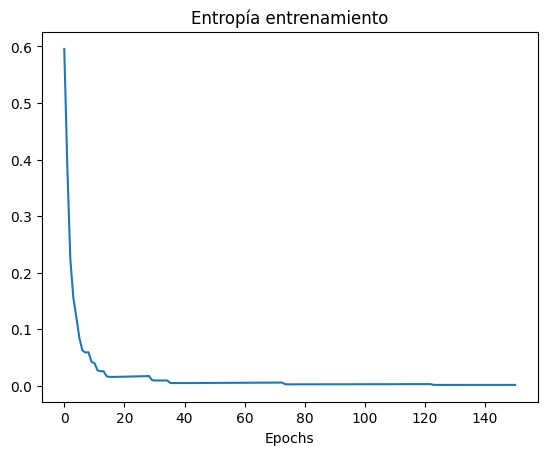

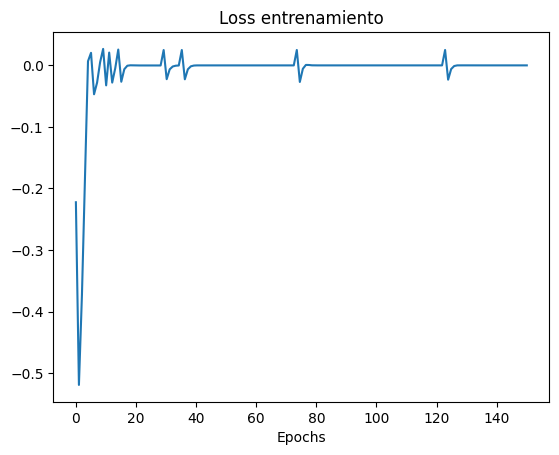

In [13]:
plot_metrics(f"{modelo_entrenado}", hiperparams_twoazeroobsonestep)

In [14]:
modelo_entrenado = "PPO_TwoAZeroObsOneStep"
env = TwoAZeroObsOneStep()
PPO = PPO_Clip_Completo(hiperparams_twoazeroobsonestep)

policy_net = PolicyNet(1, 2)

policy_net.load_state_dict(torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()

reward: 1 en 1 pasos
reward: 1 en 1 pasos
reward: 1 en 1 pasos


### TwoARandomObsOneStep

In [15]:
env = TwoARandomObsOneStep()

policy_net_twoarandomobsonestep = PolicyNet(1, 2)
value_net_twoarandomobsonestep = ValueNet(1, 1)

hiperparams_twoarandomobsonestep = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_twoarandomobsonestep,
    "value_net": value_net_twoarandomobsonestep,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 1
}

In [16]:

modelo_entrenado_twoarandomobsonestep = "PPO_TwoARandomObsOneStep"
ppo_twoarandomobsonestep = PPO_Clip_Completo(hiperparams_twoarandomobsonestep)

save_policy_file_twoarandomobsonestep = f"trained_net/basicenvs/{modelo_entrenado_twoarandomobsonestep}/actor.pth"
save_value_file_twoarandomobsonestep = f"trained_net/basicenvs/{modelo_entrenado_twoarandomobsonestep}/critic.pth"
save_metric_file_twoarandomobsonestep = f"trained_net/basicenvs/{modelo_entrenado_twoarandomobsonestep}/metrics.pt"

rewards_twoarandomobsonestep, loss_twoarandomobsonestep, entropy_twoarandomobsonestep = ppo_twoarandomobsonestep.train(
    env,
    save_file_policy=save_policy_file_twoarandomobsonestep,
    save_file_value=save_value_file_twoarandomobsonestep,
    save_metrics_file=save_metric_file_twoarandomobsonestep,
)

Epoch 1/150 -- reward: -0.19
Guardando modelos...
Epoch 2/150 -- reward: 0.12
Guardando modelos...
Epoch 3/150 -- reward: 0.47
Guardando modelos...
Epoch 4/150 -- reward: 0.31
Epoch 5/150 -- reward: 0.81
Guardando modelos...
Epoch 6/150 -- reward: 0.84
Guardando modelos...
Epoch 7/150 -- reward: 0.84
Guardando modelos...
Epoch 8/150 -- reward: 0.97
Guardando modelos...
Epoch 9/150 -- reward: 0.94
Epoch 10/150 -- reward: 0.94
Epoch 11/150 -- reward: 0.94
Epoch 12/150 -- reward: 0.91
Epoch 13/150 -- reward: 0.97
Guardando modelos...
Epoch 14/150 -- reward: 1.00
Guardando modelos...
Epoch 15/150 -- reward: 0.97
Epoch 16/150 -- reward: 1.00
Guardando modelos...
Epoch 17/150 -- reward: 1.00
Guardando modelos...
Epoch 18/150 -- reward: 1.00
Guardando modelos...
Epoch 19/150 -- reward: 0.97
Epoch 20/150 -- reward: 1.00
Guardando modelos...
Epoch 21/150 -- reward: 0.97
Epoch 22/150 -- reward: 0.97
Epoch 23/150 -- reward: 0.94
Epoch 24/150 -- reward: 1.00
Guardando modelos...
Epoch 25/150 -- re

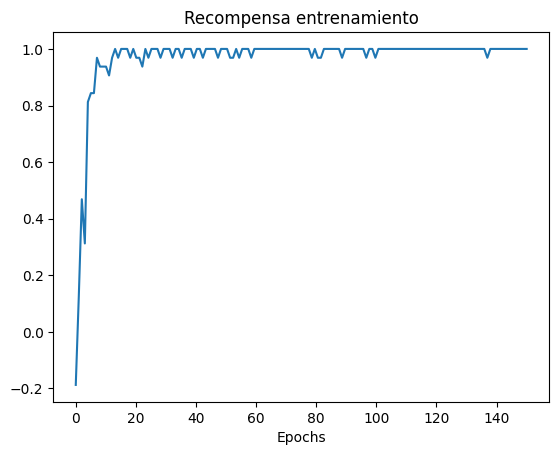

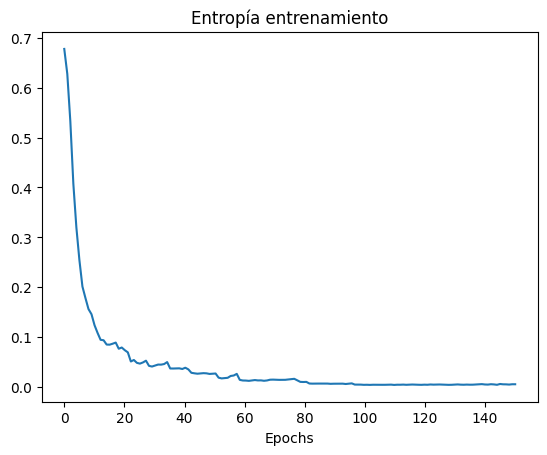

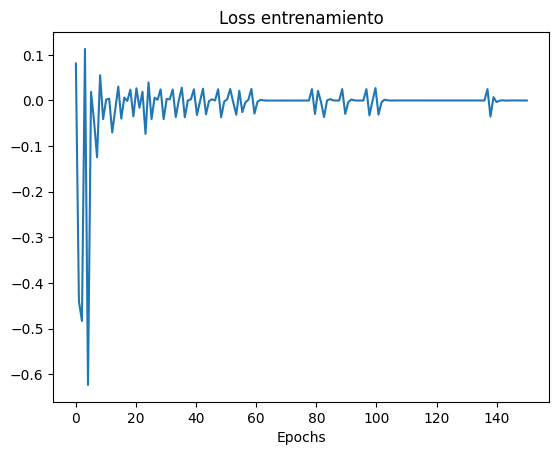

In [18]:
plot_metrics(f"{modelo_entrenado_twoarandomobsonestep}", hiperparams_twoarandomobsonestep)

In [19]:
modelo_entrenado = "PPO_TwoARandomObsOneStep"
env = TwoAZeroObsOneStep()
PPO = PPO_Clip_Completo(hiperparams_twoarandomobsonestep)

policy_net = PolicyNet(1, 2)

policy_net.load_state_dict(torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"))
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()

reward: 1 en 1 pasos
reward: 1 en 1 pasos
reward: 1 en 1 pasos


### LineWorldEasyEnv

In [21]:
env = LineWorldEasyEnv()

policy_net_lineworldeasyenv = PolicyNet(1, 2)
value_net_lineworldeasyenv = ValueNet(1, 1)

hiperparams_lineworldeasyenv = {
    "epochs": 150,
    "K": 24,               
    "batch_size": 64,     
    "policy_net": policy_net_lineworldeasyenv,
    "value_net": value_net_lineworldeasyenv,
    "clip_param": 0.2,      
    "lr": 3e-4,            
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 500   
}

In [22]:
modelo_entrenado = "PPO_LineWorldEasyEnv"
ppo_lineworldeasyenv = PPO_Clip_Completo(hiperparams_lineworldeasyenv)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_lineworldeasyenv, loss_lineworldeasyenv, entropy_lineworldeasyenv = ppo_lineworldeasyenv.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: 1.00
Guardando modelos...
Epoch 2/150 -- reward: 1.00
Guardando modelos...
Epoch 3/150 -- reward: 1.00
Guardando modelos...
Epoch 4/150 -- reward: 1.00
Guardando modelos...
Epoch 5/150 -- reward: 1.00
Guardando modelos...
Epoch 6/150 -- reward: 1.00
Guardando modelos...
Epoch 7/150 -- reward: 1.00
Guardando modelos...
Epoch 8/150 -- reward: 1.00
Guardando modelos...
Epoch 9/150 -- reward: 1.00
Guardando modelos...
Epoch 10/150 -- reward: 1.00
Guardando modelos...
Epoch 11/150 -- reward: 1.00
Guardando modelos...
Epoch 12/150 -- reward: 1.00
Guardando modelos...
Epoch 13/150 -- reward: 1.00
Guardando modelos...
Epoch 14/150 -- reward: 1.00
Guardando modelos...
Epoch 15/150 -- reward: 1.00
Guardando modelos...
Epoch 16/150 -- reward: 1.00
Guardando modelos...
Epoch 17/150 -- reward: 1.00
Guardando modelos...
Epoch 18/150 -- reward: 1.00
Guardando modelos...
Epoch 19/150 -- reward: 1.00
Guardando modelos...
Epoch 20/150 -- reward: 1.00
Guardando modelos...
Epoch 21/

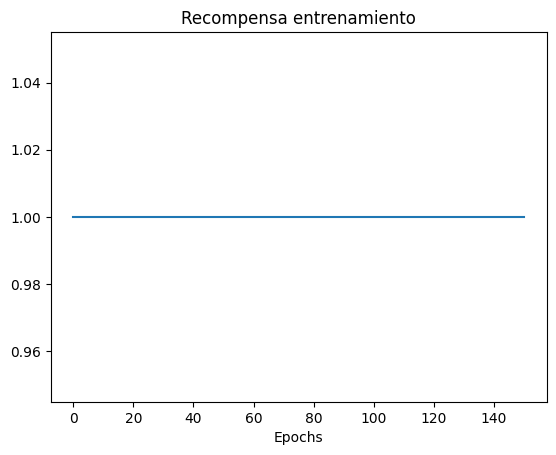

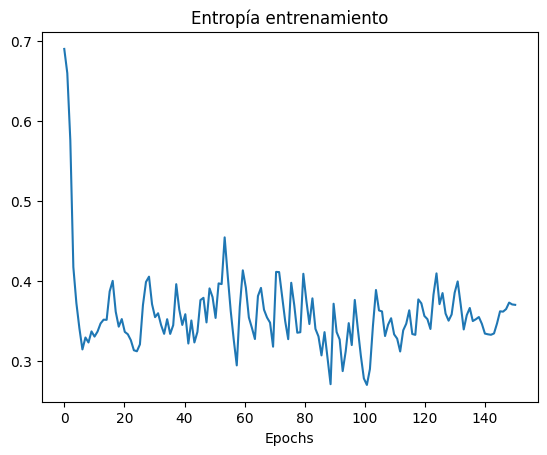

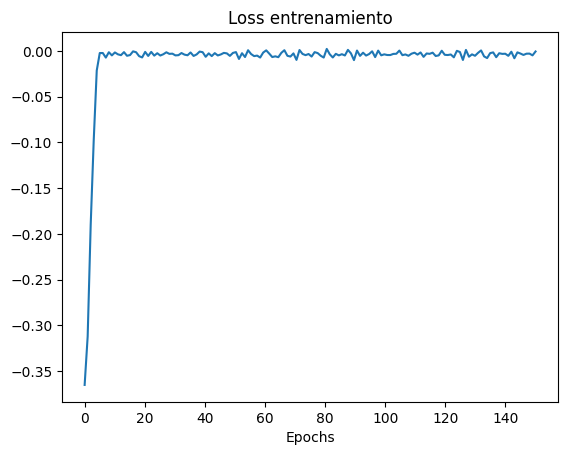

In [24]:
plot_metrics(f"{modelo_entrenado}", hiperparams_lineworldeasyenv)

In [25]:
modelo_entrenado = "PPO_LineWorldEasyEnv"
env = LineWorldEasyEnv()
PPO = PPO_Clip_Completo(hiperparams_lineworldeasyenv)

policy_net = PolicyNet(1, 2)

policy_net.load_state_dict(
    torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth")
)
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()


reward: 1 en 5 pasos
reward: 1 en 6 pasos
reward: 1 en 5 pasos


### LineWorldMirrorEnv

In [26]:
env = LineWorldMirrorEnv()

policy_net_lineworldmirrorenv = PolicyNet(1, 2)
value_net_lineworldmirrorenv = ValueNet(1, 1)

hiperparams_lineworldmirrorenv = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_lineworldmirrorenv,
    "value_net": value_net_lineworldmirrorenv,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 500
}

In [27]:

modelo_entrenado = "PPO_LineWorldMirrorEnv"
ppo_lineworldmirrorenv = PPO_Clip_Completo(hiperparams_lineworldmirrorenv)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_lineworldmirrorenv, loss_lineworldmirrorenv, entropy_lineworldmirrorenv = ppo_lineworldmirrorenv.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: -12.97
Guardando modelos...
Epoch 2/150 -- reward: -11.59
Guardando modelos...
Epoch 3/150 -- reward: -8.75
Guardando modelos...
Epoch 4/150 -- reward: -9.19
Epoch 5/150 -- reward: -8.22
Guardando modelos...
Epoch 6/150 -- reward: -8.70
Epoch 7/150 -- reward: -6.92
Guardando modelos...
Epoch 8/150 -- reward: -5.42
Guardando modelos...
Epoch 9/150 -- reward: -4.66
Guardando modelos...
Epoch 10/150 -- reward: -4.09
Guardando modelos...
Epoch 11/150 -- reward: -3.86
Guardando modelos...
Epoch 12/150 -- reward: -3.58
Guardando modelos...
Epoch 13/150 -- reward: -3.27
Guardando modelos...
Epoch 14/150 -- reward: -3.14
Guardando modelos...
Epoch 15/150 -- reward: -3.19
Epoch 16/150 -- reward: -3.09
Guardando modelos...
Epoch 17/150 -- reward: -3.14
Epoch 18/150 -- reward: -3.41
Epoch 19/150 -- reward: -3.16
Epoch 20/150 -- reward: -3.11
Epoch 21/150 -- reward: -3.27
Epoch 22/150 -- reward: -3.11
Epoch 23/150 -- reward: -3.12
Epoch 24/150 -- reward: -3.17
Epoch 25/150 -

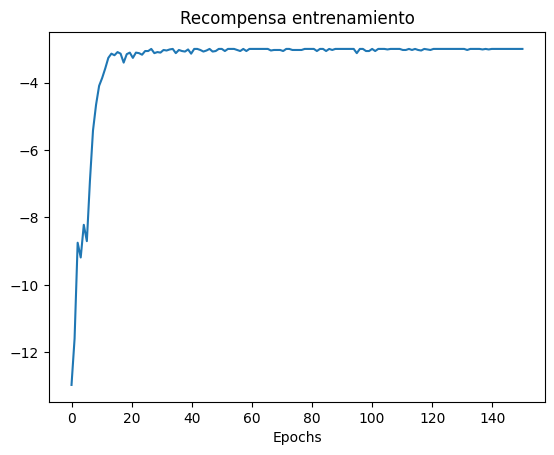

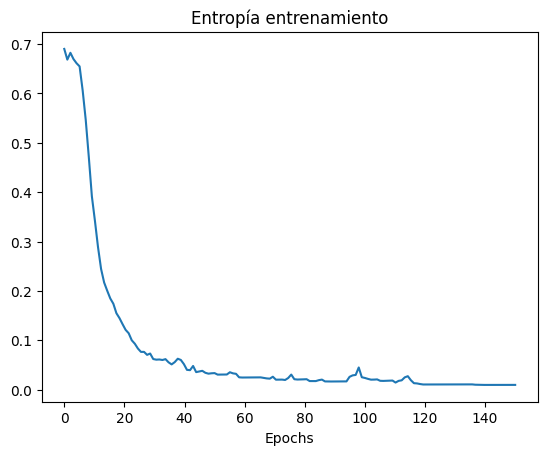

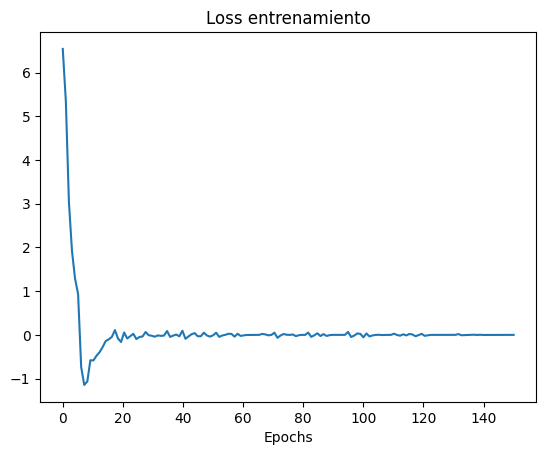

In [29]:
plot_metrics(f"{modelo_entrenado}", hiperparams_lineworldmirrorenv)

In [30]:
modelo_entrenado = "PPO_LineWorldMirrorEnv"
env = LineWorldMirrorEnv()
PPO = PPO_Clip_Completo(hiperparams_lineworldmirrorenv)

policy_net = PolicyNet(1, 2)

policy_net.load_state_dict(
    torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth")
)
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()


reward: -3 en 3 pasos
reward: -3 en 3 pasos
reward: -3 en 3 pasos


### ConstantRewardEnv

In [32]:
env = ConstantRewardEnv()

policy_net_constantrewardenv = PolicyNet(1, 1)
value_net_constantrewardenv = ValueNet(1, 1)

hiperparams_constantrewardenv = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_constantrewardenv,
    "value_net": value_net_constantrewardenv,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 1
}


In [33]:

modelo_entrenado = "PPO_ConstantRewardEnv"
ppo_constantrewardenv = PPO_Clip_Completo(hiperparams_constantrewardenv)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_constantrewardenv, loss_constantrewardenv, entropy_constantrewardenv = ppo_constantrewardenv.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: 1.00
Guardando modelos...
Epoch 2/150 -- reward: 1.00
Guardando modelos...
Epoch 3/150 -- reward: 1.00
Guardando modelos...
Epoch 4/150 -- reward: 1.00
Guardando modelos...
Epoch 5/150 -- reward: 1.00
Guardando modelos...
Epoch 6/150 -- reward: 1.00
Guardando modelos...
Epoch 7/150 -- reward: 1.00
Guardando modelos...
Epoch 8/150 -- reward: 1.00
Guardando modelos...
Epoch 9/150 -- reward: 1.00
Guardando modelos...
Epoch 10/150 -- reward: 1.00
Guardando modelos...
Epoch 11/150 -- reward: 1.00
Guardando modelos...
Epoch 12/150 -- reward: 1.00
Guardando modelos...
Epoch 13/150 -- reward: 1.00
Guardando modelos...
Epoch 14/150 -- reward: 1.00
Guardando modelos...
Epoch 15/150 -- reward: 1.00
Guardando modelos...
Epoch 16/150 -- reward: 1.00
Guardando modelos...
Epoch 17/150 -- reward: 1.00
Guardando modelos...
Epoch 18/150 -- reward: 1.00
Guardando modelos...
Epoch 19/150 -- reward: 1.00
Guardando modelos...
Epoch 20/150 -- reward: 1.00
Guardando modelos...
Epoch 21/

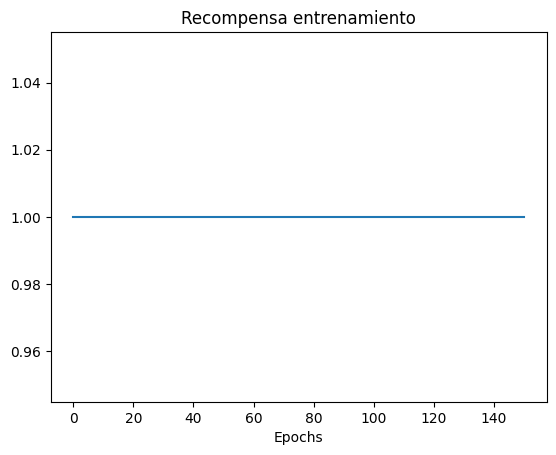

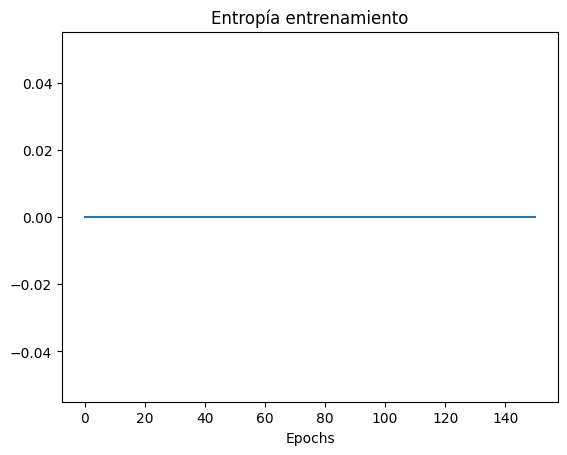

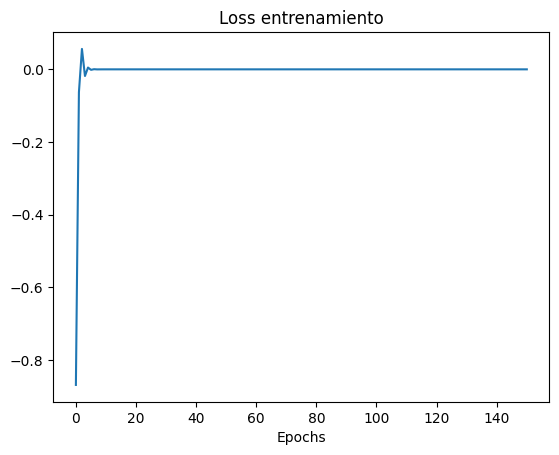

In [34]:
plot_metrics(modelo_entrenado, hiperparams_constantrewardenv)

In [35]:
modelo_entrenado = "PPO_ConstantRewardEnv"
env = ConstantRewardEnv()

PPO = PPO_Clip_Completo(hiperparams_constantrewardenv)

policy_net = PolicyNet(1, 1)
policy_net.load_state_dict(
    torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth")
)
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()


reward: 1.0 en 1 pasos
reward: 1.0 en 1 pasos
reward: 1.0 en 1 pasos


### RandomObsBinaryRewardEnv

In [36]:
env = RandomObsBinaryRewardEnv()

policy_net_randomobsbinaryrewardenv = PolicyNet(1, 1)
value_net_randomobsbinaryrewardenv = ValueNet(1, 1)

hiperparams_randomobsbinaryrewardenv = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_randomobsbinaryrewardenv,
    "value_net": value_net_randomobsbinaryrewardenv,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 1
}

In [37]:
modelo_entrenado = "PPO_RandomObsBinaryRewardEnv"
ppo_randomobsbinaryrewardenv = PPO_Clip_Completo(hiperparams_randomobsbinaryrewardenv)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_randomobsbinaryrewardenv, loss_randomobsbinaryrewardenv, entropy_randomobsbinaryrewardenv = ppo_randomobsbinaryrewardenv.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)

Epoch 1/150 -- reward: -0.03
Guardando modelos...
Epoch 2/150 -- reward: 0.12
Guardando modelos...
Epoch 3/150 -- reward: 0.12
Guardando modelos...
Epoch 4/150 -- reward: 0.06
Epoch 5/150 -- reward: -0.03
Epoch 6/150 -- reward: 0.00
Epoch 7/150 -- reward: 0.03
Epoch 8/150 -- reward: -0.12
Epoch 9/150 -- reward: -0.12
Epoch 10/150 -- reward: -0.06
Epoch 11/150 -- reward: -0.16
Epoch 12/150 -- reward: -0.06
Epoch 13/150 -- reward: 0.03
Epoch 14/150 -- reward: 0.06
Epoch 15/150 -- reward: 0.06
Epoch 16/150 -- reward: 0.00
Epoch 17/150 -- reward: 0.19
Guardando modelos...
Epoch 18/150 -- reward: -0.16
Epoch 19/150 -- reward: 0.09
Epoch 20/150 -- reward: -0.09
Epoch 21/150 -- reward: -0.12
Epoch 22/150 -- reward: 0.19
Guardando modelos...
Epoch 23/150 -- reward: 0.00
Epoch 24/150 -- reward: 0.03
Epoch 25/150 -- reward: -0.12
Epoch 26/150 -- reward: 0.09
Epoch 27/150 -- reward: 0.09
Epoch 28/150 -- reward: -0.09
Epoch 29/150 -- reward: 0.03
Epoch 30/150 -- reward: -0.09
Epoch 31/150 -- rewar

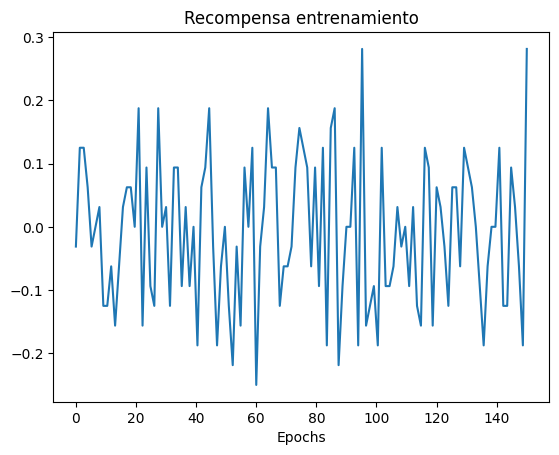

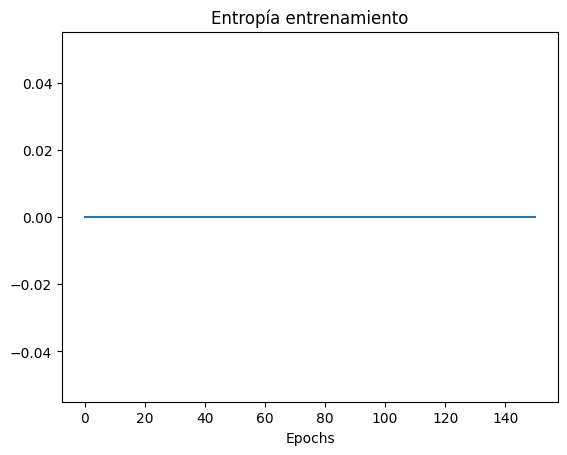

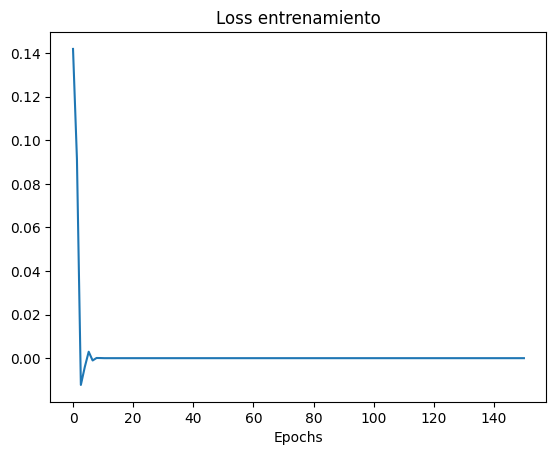

In [38]:
plot_metrics(modelo_entrenado, hiperparams_randomobsbinaryrewardenv)

In [39]:
modelo_entrenado = "PPO_RandomObsBinaryRewardEnv"
env = RandomObsBinaryRewardEnv()

PPO = PPO_Clip_Completo(hiperparams_randomobsbinaryrewardenv)

policy_net = PolicyNet(1, 1)
policy_net.load_state_dict(
    torch.load(f"trained_net/basicenvs/{modelo_entrenado}/actor.pth")
)
policy_net.eval()

PPO.policy_net = policy_net

PPO.evaluate(env, 3)
env.close()


reward: 1.0 en 1 pasos
reward: 1.0 en 1 pasos
reward: -1.0 en 1 pasos


### TwoStepDelayedRewardEnv

In [40]:
env = TwoStepDelayedRewardEnv()

policy_net_twostepdelayedrewardenv = PolicyNet(1, 1)
value_net_twostepdelayedrewardenv = ValueNet(1, 1)

hiperparams_twostepdelayedrewardenv = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "policy_net": policy_net_twostepdelayedrewardenv,
    "value_net": value_net_twostepdelayedrewardenv,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 2
}

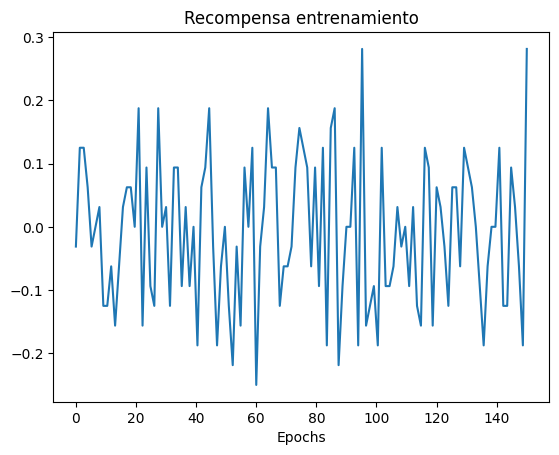

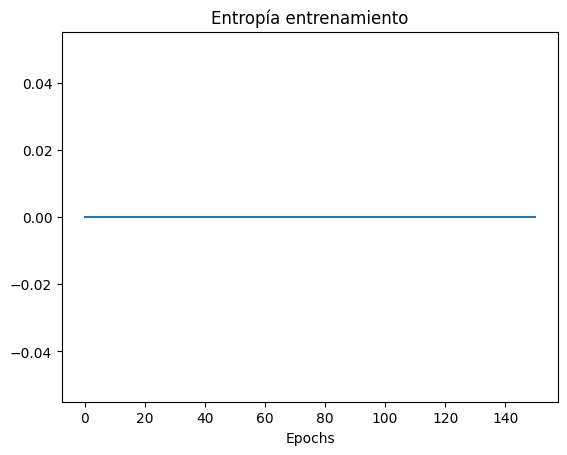

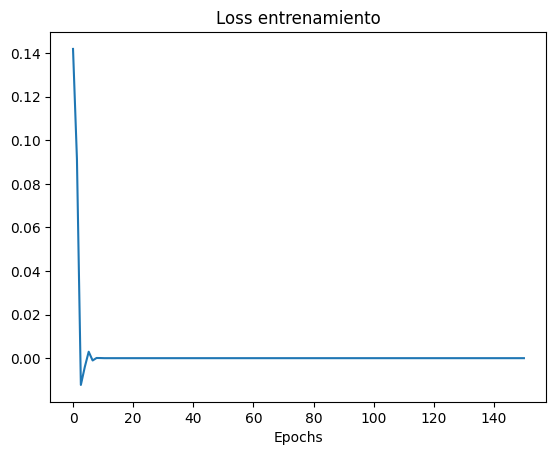

In [41]:
plot_metrics(modelo_entrenado, hiperparams_twostepdelayedrewardenv)

In [42]:
modelo_entrenado = "PPO_TwoStepDelayedRewardEnv"
ppo_twostepdelayedrewardenv = PPO_Clip_Completo(hiperparams_twostepdelayedrewardenv)

save_policy_file = f"trained_net/basicenvs/{modelo_entrenado}/actor.pth"
save_value_file = f"trained_net/basicenvs/{modelo_entrenado}/critic.pth"
save_metric_file = f"trained_net/basicenvs/{modelo_entrenado}/metrics.pt"

rewards_twostepdelayedrewardenv, loss_twostepdelayedrewardenv, entropy_twostepdelayedrewardenv = ppo_twostepdelayedrewardenv.train(
    env,
    save_file_policy=save_policy_file,
    save_file_value=save_value_file,
    save_metrics_file=save_metric_file,
)


Epoch 1/150 -- reward: 1.00
Guardando modelos...
Epoch 2/150 -- reward: 1.00
Guardando modelos...
Epoch 3/150 -- reward: 1.00
Guardando modelos...
Epoch 4/150 -- reward: 1.00
Guardando modelos...
Epoch 5/150 -- reward: 1.00
Guardando modelos...
Epoch 6/150 -- reward: 1.00
Guardando modelos...
Epoch 7/150 -- reward: 1.00
Guardando modelos...
Epoch 8/150 -- reward: 1.00
Guardando modelos...
Epoch 9/150 -- reward: 1.00
Guardando modelos...
Epoch 10/150 -- reward: 1.00
Guardando modelos...
Epoch 11/150 -- reward: 1.00
Guardando modelos...
Epoch 12/150 -- reward: 1.00
Guardando modelos...
Epoch 13/150 -- reward: 1.00
Guardando modelos...
Epoch 14/150 -- reward: 1.00
Guardando modelos...
Epoch 15/150 -- reward: 1.00
Guardando modelos...
Epoch 16/150 -- reward: 1.00
Guardando modelos...
Epoch 17/150 -- reward: 1.00
Guardando modelos...
Epoch 18/150 -- reward: 1.00
Guardando modelos...
Epoch 19/150 -- reward: 1.00
Guardando modelos...
Epoch 20/150 -- reward: 1.00
Guardando modelos...
Epoch 21/

(CartPole-v1) Acá con Stable Baselines 3:

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 20.7     |
|    ep_rew_mean     | 20.7     |
| time/              |          |
|    fps             | 6952     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 24.3        |
|    ep_rew_mean          | 24.3        |
| time/                   |             |
|    fps                  | 3088        |
|    iterations           | 2           |
|    time_elapsed         | 0           |
|    total_timesteps      | 1024        |
| train/                  |             |
|    approx_kl            | 0.007136492 |
|    clip_fraction        | 0.0658      |
|    clip_range           | 0.2         |
|    entropy_loss   

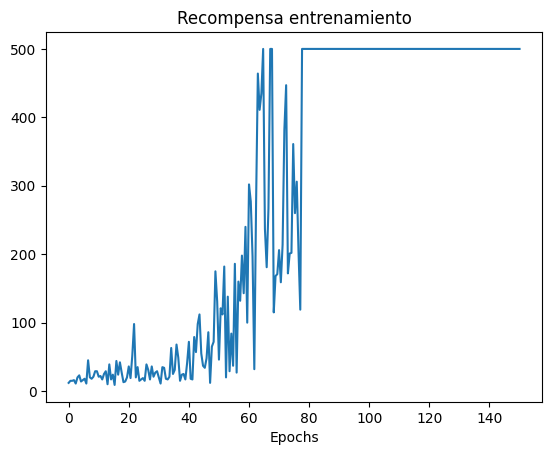

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Recompensa episodio 1: 500.0
Recompensa episodio 2: 500.0
Recompensa episodio 3: 500.0


In [43]:
def plot_metrics(modelo_entrenado, hiperparams):
    data = torch.load(f"trained_net/{modelo_entrenado}/metrics.pt")

    reward = data["rewards"]
    plt.plot(np.linspace(0, hiperparams["epochs"], len(reward)), reward)
    plt.title("Recompensa entrenamiento")
    plt.xlabel("Epochs")
    plt.show()


class MetricsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.rewards = []
        self.losses = []
        self.entropies = []

    def _on_step(self) -> bool:
        if "episode" in self.locals["infos"][0]:
            ep_reward = self.locals["infos"][0]["episode"]["r"]
            self.rewards.append(ep_reward)

        if "loss" in self.model.logger.name_to_value:
            self.losses.append(self.model.logger.name_to_value["loss"])

        if "entropy_loss" in self.model.logger.name_to_value:
            self.entropies.append(self.model.logger.name_to_value["entropy_loss"])

        return True


env = gym.make("CartPole-v1")

modelo_entrenado = "PPO_CartPole_sb3"
save_folder = f"trained_net/{modelo_entrenado}"
os.makedirs(save_folder, exist_ok=True)

# Nuestro formato
hiperparams_cartpole = {
    "epochs": 150,
    "K": 24,
    "batch_size": 64,
    "clip_param": 0.2,
    "lr": 3e-4,
    "discount_factor": 0.99,
    "gae_lambda": 0.95,
    "entropy_coeficient": 0.01,
    "max_length": 500,
}

# mas o menos este es el equivalente en SB3
model = PPO_sb3(
    policy="MlpPolicy",
    env=env,
    learning_rate=hiperparams_cartpole["lr"],
    n_steps=512,
    batch_size=hiperparams_cartpole["batch_size"],
    n_epochs=hiperparams_cartpole["K"],
    gamma=hiperparams_cartpole["discount_factor"],
    gae_lambda=hiperparams_cartpole["gae_lambda"],
    clip_range=hiperparams_cartpole["clip_param"],
    ent_coef=hiperparams_cartpole["entropy_coeficient"],
    verbose=1,
)

metrics = MetricsCallback()

total_timesteps = hiperparams_cartpole["epochs"] * hiperparams_cartpole["max_length"]

model.learn(
    total_timesteps=total_timesteps,
    callback=metrics
)

model.save(f"{save_folder}/ppo_sb3_cartpole_model")

torch.save({
    "rewards": metrics.rewards,
    "losses": metrics.losses,
    "entropy": metrics.entropies
}, f"{save_folder}/metrics.pt")

plot_metrics(modelo_entrenado, hiperparams_cartpole)

env_eval = gym.make("CartPole-v1", render_mode="human")

model = PPO_sb3.load(f"{save_folder}/ppo_sb3_cartpole_model", env=env_eval)

def evaluate(model, env, episodes=3):
    for ep in range(episodes):
        obs, info = env.reset()
        done = False
        total_r = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_r += reward
            done = terminated or truncated
        print(f"Recompensa episodio {ep+1}: {total_r}")

evaluate(model, env_eval, 3)
env_eval.close()

Para el informe, los sobrepongo a los dos

In [44]:
def compare_reward_curves(reward_dict, epochs):
    """
    reward_dict: dict con nombre → lista de rewards
    epochs: número total de epochs originales
    cut_last: cuántas epochs cortar al final
    """

    plt.figure(figsize=(10, 5))

    # nuevo límite
    effective_epochs = epochs

    for label, reward_list in reward_dict.items():

        # cortar la lista
        rewards = np.array(reward_list[:effective_epochs])

        # eje X
        x = np.linspace(0, effective_epochs, len(rewards))

        # graficar
        plt.plot(x, rewards, label=label)

    plt.title(f"Comparación de Rewards")
    plt.xlabel("Epochs")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

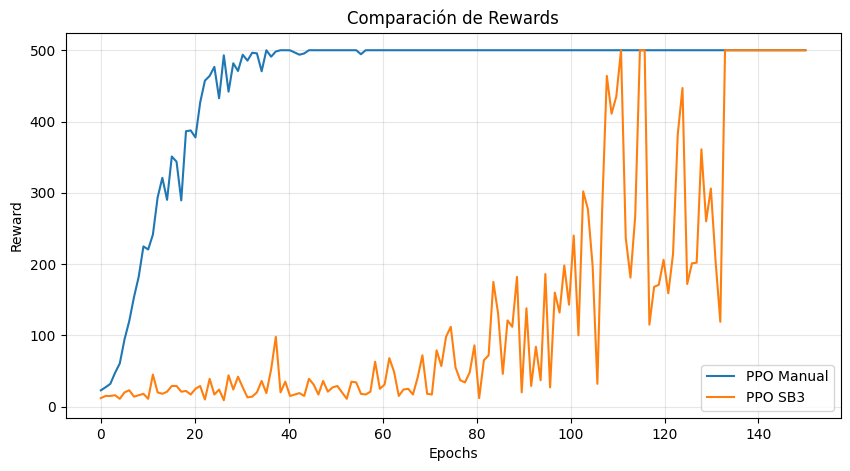

In [46]:
rewards_manual = torch.load("trained_net/basicenvs/PPO_CartPole_v1/metrics.pt", weights_only=False)["rewards"]
rewards_sb3 = torch.load("trained_net/PPO_CartPole_sb3/metrics.pt", weights_only=False)["rewards"]

reward_dict = {
    "PPO Manual": rewards_manual,
    "PPO SB3": rewards_sb3
}

compare_reward_curves(
    reward_dict, 
    epochs=150, 
)
